# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [1]:
# Replace None with your code
# Imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Create connection to database
conn = sqlite3.connect('data.sqlite')

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.

In [2]:
# Replace None with your code
# California customers with credit limit over 25,000
california_high_credit = pd.read_sql("""
    SELECT customerNumber, customerName, city, state, creditLimit
    FROM customers
    WHERE state = 'CA' AND creditLimit > 25000
""", conn)

california_high_credit

,customerNumber,customerName,city,state,creditLimit
0,124,Mini Gifts Distributors Ltd.,San Rafael,CA,210500.00
1,129,Mini Wheels Co.,San Francisco,CA,64600.00
2,161,Technics Stores Inc.,Burlingame,CA,84600.00
3,205,Toys4GrownUps.com,Pasadena,CA,90700.00
4,219,Boards & Toys Co.,Glendale,CA,11000.00
5,239,Collectable Mini Designs Co.,San Diego,CA,105000.00
6,321,Corporate Gift Ideas Co.,San Francisco,CA,105000.00
7,347,"Men 'R' US Retailers, Ltd.",Los Angeles,CA,57700.00
8,450,The Sharp Gifts Warehouse,San Jose,CA,77600.00
9,475,West Coast Collectables Co.,Burbank,CA,55400.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [3]:
# Replace None with your code
# International customers (non-US) with "Collect" in their name
collect_customers = pd.read_sql("""
    SELECT customerNumber, customerName, country, city
    FROM customers
    WHERE country != 'USA' AND customerName LIKE '%Collect%'
""", conn)

collect_customers

,customerNumber,customerName,country,city
0,114,"Australian Collectors, Co.",Australia,Melbourne
1,189,"Clover Collections, Co.",Ireland,Dublin
2,201,"UK Collectables, Ltd.",UK,Liverpool
3,211,"King Kong Collectables, Co.",Hong Kong,Central Hong Kong
4,227,Heintze Collectables,Denmark,Århus
5,260,"Royal Canadian Collectables, Ltd.",Canada,Tsawassen
6,293,BG&E Collectables,Switzerland,Fribourg
7,353,Reims Collectables,France,Reims
8,376,Precious Collectables,Switzerland,Bern
9,382,Salzburg Collectables,Austria,Salzburg


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!

The WHERE clause uses two filters: country != 'USA' and customerName LIKE '%Collect%'. The != operator excludes any customers from the USA, ensuring we only get international customers. The LIKE operator with %Collect% finds any customer name that contains "Collect" anywhere in the name (the % wildcards mean any characters can come before or after). Both conditions must be true for a customer to be included, ensuring we only target international customers with "Collect" in their name.

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [11]:
# Replace None with your code
# Average credit limit by state for US customers
state_credit_avg = pd.read_sql("""
    SELECT state, AVG(creditLimit) as avg_credit_limit, COUNT(*) as customer_count
    FROM customers
    WHERE country = 'USA' AND state IS NOT NULL
    GROUP BY state
    ORDER BY avg_credit_limit DESC
""", conn)

state_credit_avg

,state,avg_credit_limit,customer_count
0,NH,114200.000000,1
1,NY,89966.666667,6
2,PA,84766.666667,3
3,CA,83854.545455,11
4,NV,71800.000000,1
5,MA,70755.555556,9
6,CT,57350.000000,4
7,NJ,43000.000000,1


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

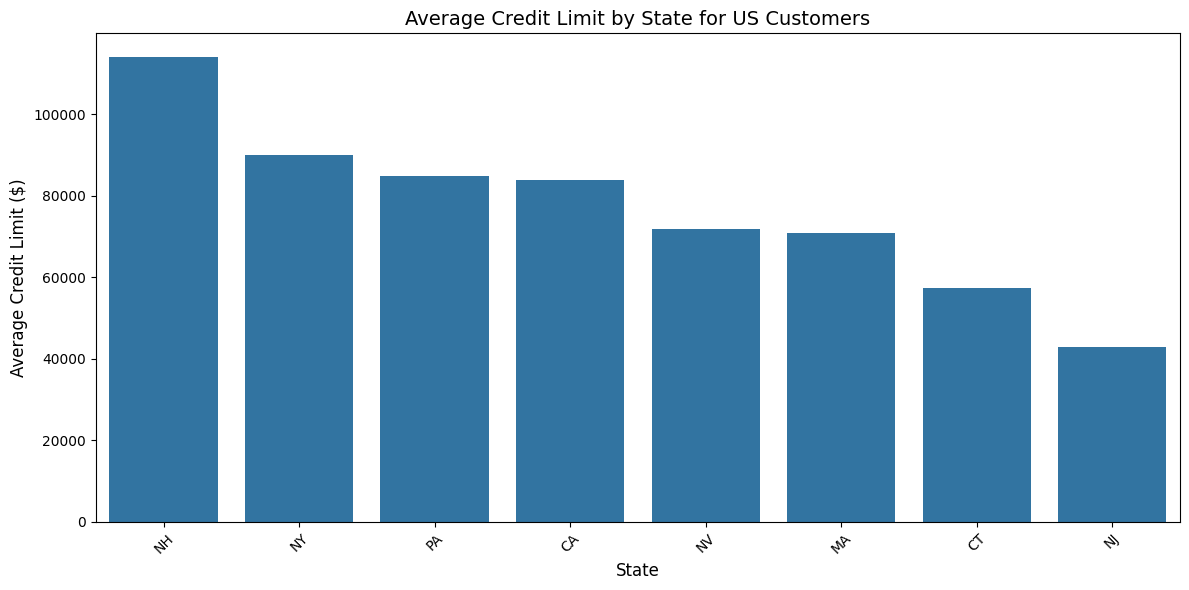

In [12]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state
# Visual: Average credit limit by state
plt.figure(figsize=(12, 6))
sns.barplot(data=state_credit_avg, x='state', y='avg_credit_limit')
plt.title('Average Credit Limit by State for US Customers', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Credit Limit ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [13]:
# Replace None with your code
# Top 10 customers by total payments
top_customers = pd.read_sql("""
    SELECT c.customerNumber, c.customerName, SUM(p.amount) as total_payments
    FROM customers c
    JOIN payments p ON c.customerNumber = p.customerNumber
    GROUP BY c.customerNumber, c.customerName
    ORDER BY total_payments DESC
    LIMIT 10
""", conn)

top_customers

,customerNumber,customerName,total_payments
0,141,Euro+ Shopping Channel,715738.98
1,124,Mini Gifts Distributors Ltd.,584188.24
2,114,"Australian Collectors, Co.",180585.07
3,151,Muscle Machine Inc,177913.95
4,148,"Dragon Souveniers, Ltd.",156251.03
5,323,"Down Under Souveniers, Inc",154622.08
6,187,"AV Stores, Co.",148410.09
7,276,"Anna's Decorations, Ltd",137034.22
8,321,Corporate Gift Ideas Co.,132340.78
9,146,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_35720\1759086779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers, y='customerName', x='total_payments', palette='viridis')


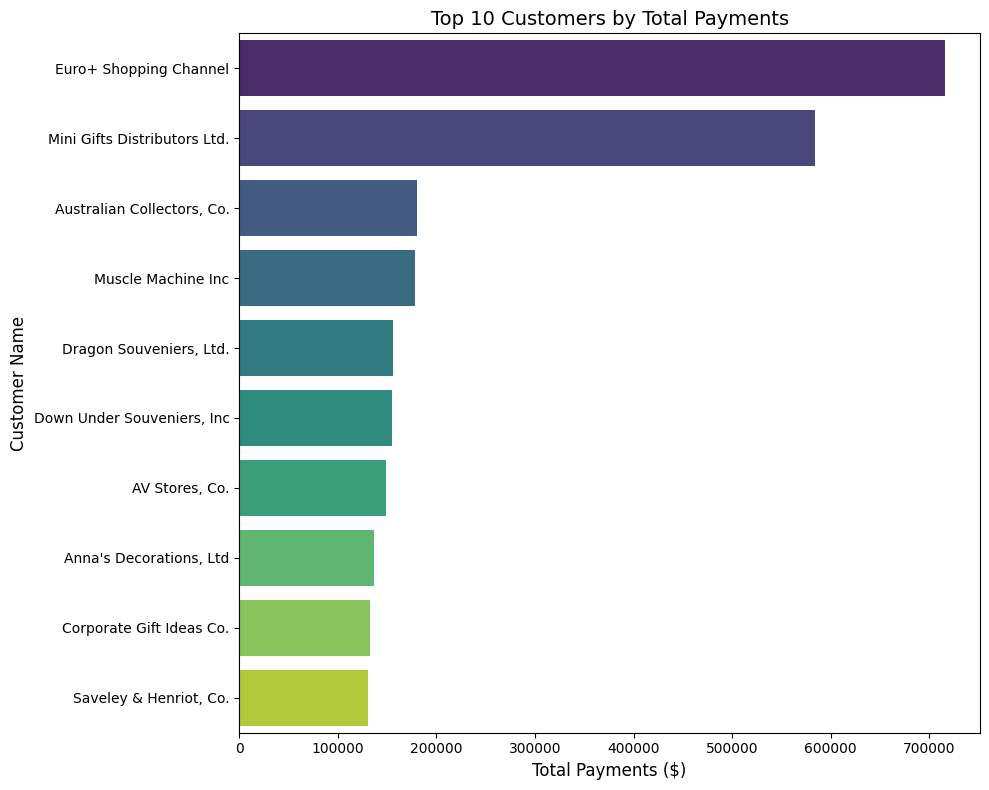

In [14]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments
# Visual: Top 10 customers by total payments
plt.figure(figsize=(10, 8))
sns.barplot(data=top_customers, y='customerName', x='total_payments', palette='viridis')
plt.title('Top 10 Customers by Total Payments', fontsize=14)
plt.xlabel('Total Payments ($)', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)
plt.tight_layout()
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [15]:
# Replace None with you code
# Products purchased 10+ units by each customer
customer_product_qty = pd.read_sql("""
    SELECT c.customerName, p.productName, SUM(od.quantityOrdered) as total_quantity
    FROM customers c
    JOIN orders o ON c.customerNumber = o.customerNumber
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    JOIN products p ON od.productCode = p.productCode
    GROUP BY c.customerName, p.productName
    HAVING total_quantity >= 10
    ORDER BY total_quantity ASC
""", conn)

customer_product_qty

,customerName,productName,total_quantity
0,"Extreme Desk Decorations, Ltd",1961 Chevrolet Impala,10
1,Petit Auto,1913 Ford Model T Speedster,10
2,La Rochelle Gifts,1954 Greyhound Scenicruiser,11
3,Tekni Collectables Inc.,American Airlines: B767-300,11
4,The Sharp Gifts Warehouse,1969 Chevrolet Camaro Z28,13
...,...,...,...
2526,Euro+ Shopping Channel,2002 Chevy Corvette,174
2527,Euro+ Shopping Channel,1957 Chevy Pickup,183
2528,Euro+ Shopping Channel,1970 Dodge Coronet,197
2529,Euro+ Shopping Channel,1958 Chevy Corvette Limited Edition,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [16]:
# Replace None with your code
# Product line analysis
product_line_analysis = pd.read_sql("""
    SELECT p.productLine, 
           COUNT(DISTINCT p.productCode) as number_of_products, 
           SUM(od.quantityOrdered) as total_quantity_ordered
    FROM products p
    JOIN orderdetails od ON p.productCode = od.productCode
    GROUP BY p.productLine
    ORDER BY total_quantity_ordered DESC
""", conn)

product_line_analysis

,productLine,number_of_products,total_quantity_ordered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

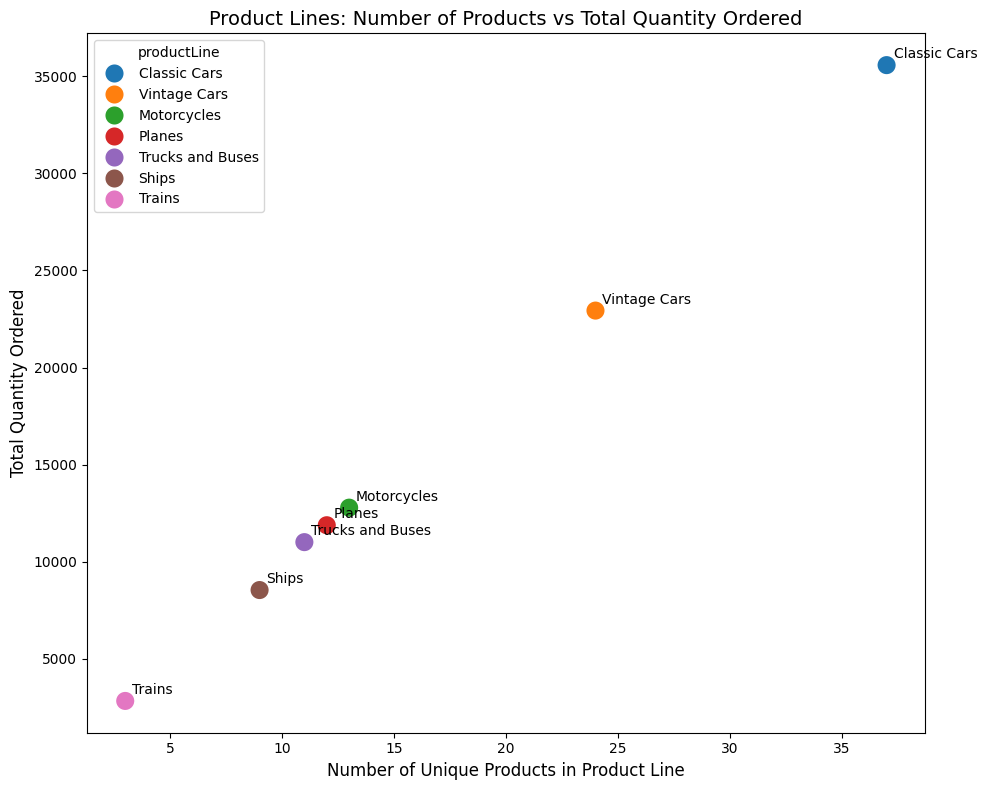

In [17]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered
# Visual: Relationship between number of products and total quantity ordered
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(data=product_line_analysis, 
                          x='number_of_products', 
                          y='total_quantity_ordered', 
                          s=200, 
                          hue='productLine')
plt.title('Product Lines: Number of Products vs Total Quantity Ordered', fontsize=14)
plt.xlabel('Number of Unique Products in Product Line', fontsize=12)
plt.ylabel('Total Quantity Ordered', fontsize=12)

# Add labels for each point
for i, row in product_line_analysis.iterrows():
    plt.annotate(row['productLine'], 
                 (row['number_of_products'], row['total_quantity_ordered']),
                 xytext=(5, 5), 
                 textcoords='offset points')

plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!

I chose a scatter plot because it effectively shows the relationship between two numerical variables: number of products and total quantity ordered. This chart type allows us to see if there's a correlation - whether product lines with more products tend to have higher order quantities. The scatter plot clearly shows each product line as a distinct point, and adding labels identifies which line is which. From this visualization, we can see that Classic Cars has both the highest number of products AND the highest quantity ordered, suggesting that product variety within a line may drive sales. However, other lines like Vintage Cars have moderate product counts but relatively lower orders, indicating that quantity of products alone doesn't guarantee high sales volume.

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [18]:
# Replace None with your code
# Employees in offices with fewer than 5 employees
remote_office_employees = pd.read_sql("""
    SELECT e.employeeNumber, e.firstName, e.lastName, e.jobTitle, 
           e.reportsTo, o.city, o.country, o.officeCode
    FROM employees e
    JOIN offices o ON e.officeCode = o.officeCode
    WHERE o.officeCode IN (
        SELECT officeCode
        FROM employees
        GROUP BY officeCode
        HAVING COUNT(*) < 5
    )
""", conn)

remote_office_employees

,employeeNumber,firstName,lastName,jobTitle,reportsTo,city,country,officeCode
0,1188,Julie,Firrelli,Sales Rep,1143,Boston,USA,2
1,1216,Steve,Patterson,Sales Rep,1143,Boston,USA,2
2,1286,Foon Yue,Tseng,Sales Rep,1143,NYC,USA,3
3,1323,George,Vanauf,Sales Rep,1143,NYC,USA,3
4,1621,Mami,Nishi,Sales Rep,1056,Tokyo,Japan,5
5,1625,Yoshimi,Kato,Sales Rep,1621,Tokyo,Japan,5
6,1088,William,Patterson,Sales Manager (APAC),1056,Sydney,Australia,6
7,1611,Andy,Fixter,Sales Rep,1088,Sydney,Australia,6
8,1612,Peter,Marsh,Sales Rep,1088,Sydney,Australia,6
9,1619,Tom,King,Sales Rep,1088,Sydney,Australia,6


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!

The subquery first identifies which office codes have fewer than 5 employees by grouping employees by officeCode and using HAVING COUNT(*) < 5. This gives us a list of small offices. The main query then uses this list with the IN operator to filter employees who work in those office codes. By joining with the offices table, we also get location information (city, country). This approach ensures we only get employees from offices that meet the "small office" criteria, and the subquery handles the dynamic calculation of office sizes rather than hardcoding specific office codes.

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [20]:
# Replace None with your code
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [23]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

In [24]:
# Begin your code here
# 1. Check basic info about movies (2010-2019 range)
movie_basics_info = pd.read_sql("""
    SELECT COUNT(*) as total_movies,
           MIN(start_year) as earliest_year,
           MAX(start_year) as latest_year,
           COUNT(DISTINCT genres) as unique_genre_combinations
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
""", conn4)

movie_basics_info

,total_movies,earliest_year,latest_year,unique_genre_combinations
0,145081,2010,2019,1084


In [25]:
# 2. Genre distribution
genre_distribution = pd.read_sql("""
    SELECT genres, COUNT(*) as movie_count
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
      AND genres IS NOT NULL
    GROUP BY genres
    ORDER BY movie_count DESC
    LIMIT 20
""", conn4)

genre_distribution

,genres,movie_count
0,Documentary,32106
1,Drama,21306
2,Comedy,9096
3,Horror,4309
4,"Comedy,Drama",3497
5,Thriller,2984
6,Action,2164
7,"Biography,Documentary",2115
8,"Drama,Romance",2069
9,"Comedy,Drama,Romance",1554


In [26]:
# 3. Rating distribution
rating_distribution = pd.read_sql("""
    SELECT mr.averagerating, COUNT(*) as movie_count
    FROM movie_ratings mr
    JOIN movie_basics mb ON mr.movie_id = mb.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
    GROUP BY CAST(mr.averagerating AS INTEGER)
    ORDER BY mr.averagerating
""", conn4)

rating_distribution

,averagerating,movie_count
0,1.9,419
1,2.3,1315
2,3.9,3527
3,4.1,7122
4,5.9,13708
5,6.9,20858
6,7.0,17459
7,8.1,8022
8,9.1,1410
9,10.0,16


In [27]:
# 4. Top rated movies by genre (example with 'Action')
top_action_movies = pd.read_sql("""
    SELECT mb.primary_title, mb.start_year, mr.averagerating, mr.numvotes, mb.genres
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
      AND mb.genres LIKE '%Action%'
      AND mr.numvotes > 5000
    ORDER BY mr.averagerating DESC
    LIMIT 10
""", conn4)

top_action_movies

,primary_title,start_year,averagerating,numvotes,genres
0,The Mountain II,2016,9.3,100568,"Action,Drama,War"
1,Inception,2010,8.8,1841066,"Action,Adventure,Sci-Fi"
2,Avengers: Endgame,2019,8.8,441135,"Action,Adventure,Sci-Fi"
3,Ratsasan,2018,8.8,10518,"Action,Crime,Thriller"
4,Vada Chennai,2018,8.7,6217,"Action,Crime"
5,Vikram Vedha,2017,8.7,18704,"Action,Crime,Thriller"
6,The Stage,2018,8.6,15407,"Action,Drama"
7,Uri: The Surgical Strike,2019,8.6,30292,"Action,Drama,War"
8,Avengers: Infinity War,2018,8.5,670926,"Action,Adventure,Sci-Fi"
9,Spider-Man: Into the Spider-Verse,2018,8.5,210869,"Action,Adventure,Animation"


In [28]:
# 5. Director analysis - average rating by director
director_ratings = pd.read_sql("""
    SELECT p.primary_name as director_name, 
           COUNT(DISTINCT mb.movie_id) as movie_count,
           AVG(mr.averagerating) as avg_rating
    FROM directors d
    JOIN persons p ON d.person_id = p.person_id
    JOIN movie_basics mb ON d.movie_id = mb.movie_id
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
      AND mr.numvotes > 1000
    GROUP BY p.person_id, p.primary_name
    HAVING movie_count >= 3
    ORDER BY avg_rating DESC
    LIMIT 15
""", conn4)

director_ratings

,director_name,movie_count,avg_rating
0,Steve Ravic,4,8.700000
1,Quentin Tarantino,4,8.700000
2,Christopher Nolan,4,8.437500
3,Vetrimaaran,3,8.340000
4,Anthony Russo,4,8.246667
5,Joe Russo,4,8.246667
6,Alper Caglar,3,8.200000
7,Jeethu Joseph,4,8.133333
8,M. Manikandan,3,8.120000
9,Nuri Bilge Ceylan,3,8.100000


In [29]:
# 6. Runtime analysis
runtime_analysis = pd.read_sql("""
    SELECT 
        CASE 
            WHEN mb.runtime_minutes < 90 THEN 'Short (<90 min)'
            WHEN mb.runtime_minutes BETWEEN 90 AND 120 THEN 'Medium (90-120 min)'
            WHEN mb.runtime_minutes BETWEEN 121 AND 150 THEN 'Long (121-150 min)'
            ELSE 'Very Long (>150 min)'
        END as runtime_category,
        AVG(mr.averagerating) as avg_rating,
        COUNT(*) as movie_count
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
      AND mb.runtime_minutes IS NOT NULL
    GROUP BY runtime_category
    ORDER BY avg_rating DESC
""", conn4)

runtime_analysis

,runtime_category,avg_rating,movie_count
0,Very Long (>150 min),6.705601,1339
1,Long (121-150 min),6.418887,5247
2,Short (<90 min),6.393324,28099
3,Medium (90-120 min),6.225929,31551


In [30]:
# 7. Year-over-year trend analysis
yearly_trends = pd.read_sql("""
    SELECT mb.start_year,
           COUNT(*) as movie_count,
           AVG(mr.averagerating) as avg_rating,
           AVG(mb.runtime_minutes) as avg_runtime
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
      AND mb.runtime_minutes IS NOT NULL
    GROUP BY mb.start_year
    ORDER BY mb.start_year
""", conn4)

yearly_trends

,start_year,movie_count,avg_rating,avg_runtime
0,2010,6101,6.270546,92.522046
1,2011,6626,6.292937,94.183821
2,2012,6923,6.292157,99.269825
3,2013,7272,6.292616,92.437706
4,2014,7600,6.321421,93.336053
5,2015,7699,6.264541,93.449929
6,2016,7839,6.330769,93.744483
7,2017,7755,6.365364,94.838040
8,2018,6610,6.377322,96.970348
9,2019,1811,6.652126,100.156267


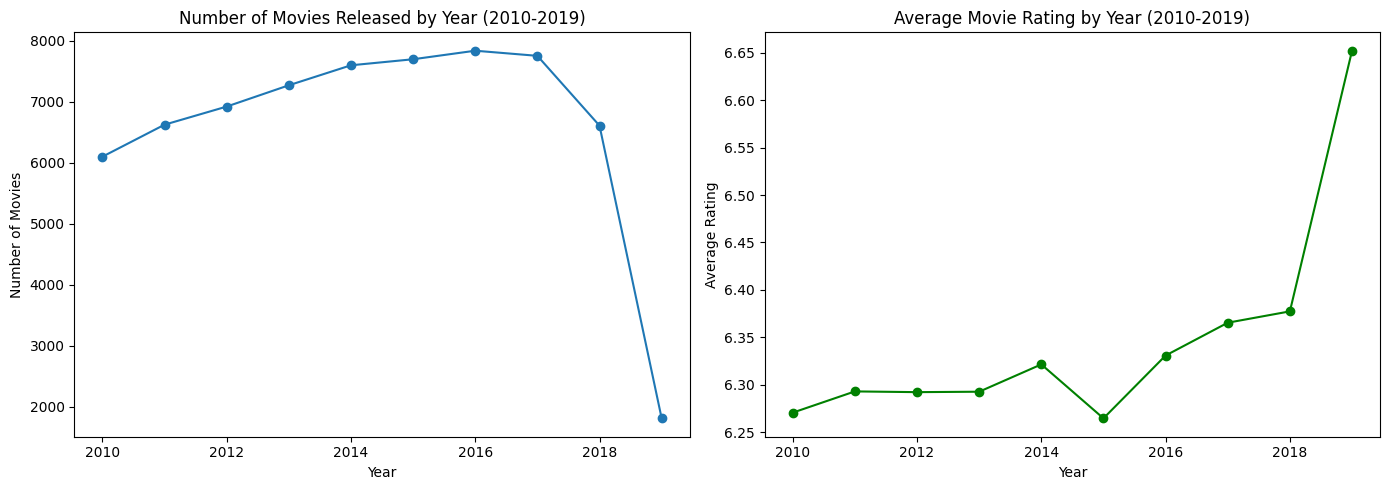

In [31]:
# Visualization: Yearly trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Movie count by year
axes[0].plot(yearly_trends['start_year'], yearly_trends['movie_count'], marker='o')
axes[0].set_title('Number of Movies Released by Year (2010-2019)', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Movies')

# Average rating by year
axes[1].plot(yearly_trends['start_year'], yearly_trends['avg_rating'], marker='o', color='green')
axes[1].set_title('Average Movie Rating by Year (2010-2019)', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

In [32]:
# 8. Voting patterns - popularity vs rating
voting_analysis = pd.read_sql("""
    SELECT mb.primary_title, mr.averagerating, mr.numvotes,
           CASE 
               WHEN mr.numvotes < 1000 THEN 'Low (<1K)'
               WHEN mr.numvotes BETWEEN 1000 AND 10000 THEN 'Medium (1K-10K)'
               WHEN mr.numvotes BETWEEN 10001 AND 50000 THEN 'High (10K-50K)'
               ELSE 'Very High (>50K)'
           END as popularity_category
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
    ORDER BY mr.numvotes DESC
    LIMIT 50
""", conn4)

voting_analysis.head(10)

,primary_title,averagerating,numvotes,popularity_category
0,Inception,8.8,1841066,Very High (>50K)
1,The Dark Knight Rises,8.4,1387769,Very High (>50K)
2,Interstellar,8.6,1299334,Very High (>50K)
3,Django Unchained,8.4,1211405,Very High (>50K)
4,The Avengers,8.1,1183655,Very High (>50K)
5,The Wolf of Wall Street,8.2,1035358,Very High (>50K)
6,Shutter Island,8.1,1005960,Very High (>50K)
7,Guardians of the Galaxy,8.1,948394,Very High (>50K)
8,Deadpool,8.0,820847,Very High (>50K)
9,The Hunger Games,7.2,795227,Very High (>50K)


In [33]:
# Close connection
conn4.close()